### homoFRET

In [ ]:
distances = np.arange(1, 20, 1)
rates = []
for distance in distances:
    rate = fo.calculate_fret_rate(distance, 1e8, j_cy5, 0.66, 1)
    rates.append(rate)

efficiencies = []
for rate in rates:
    e = fo.calculate_fret_efficiency(rate, 1e-9)
    efficiencies.append(e)

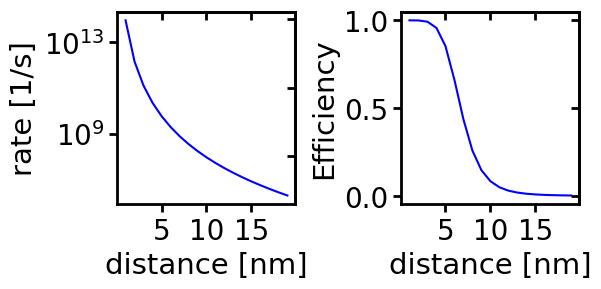

In [ ]:
axes = fi.universal_figure(type_='line', data=[distances, rates], ylabel='rate [1/s]', xlabel='distance [nm]', yscale='log', ncols=2)
_ = fi.universal_figure(data=[distances, efficiencies], ylabel='Efficiency', xlabel='distance [nm]', axes=axes[0, 1])
axes[0, 0].get_figure().tight_layout()

### OFF FRET

In [ ]:
distances = np.arange(1, 20, 1)
rates = []
for distance in distances:
    rate = fo.calculate_fret_rate(distance, 1e8, j_off, 0.66, 1)
    rates.append(rate)

efficiencies = []
for rate in rates:
    e = fo.calculate_fret_efficiency(rate, 1e-9)
    efficiencies.append(e)

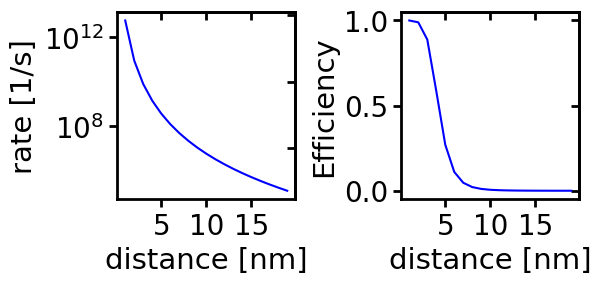

In [ ]:
axes = fi.universal_figure(type_='line', data=[distances, rates], ylabel='rate [1/s]', xlabel='distance [nm]', yscale='log', ncols=2)
_ = fi.universal_figure(data=[distances, efficiencies], ylabel='Efficiency', xlabel='distance [nm]', axes=axes[0, 1])
axes[0, 0].get_figure().tight_layout()

# ON/OFF validations

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi
import src.formulas as fo

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\markovmodels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### OFF generated by S1 same order of magnitude as by T1

In [22]:
number_fluorophores = 1
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [23]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=10000, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

In [24]:
off_index = np.where(simulation.state_series[0] == tr.SingleState.OFF.value)[0]
high_diffs = np.where(np.diff(off_index) > 1)[0]
states, numbers = np.unique(simulation.state_series[0][off_index[high_diffs+1]-1], return_counts=True)

In [25]:
states, numbers

(array([1, 3], dtype=int8), array([174,  24], dtype=int64))

Text(0.5, 100, 'ratio: 7.25')

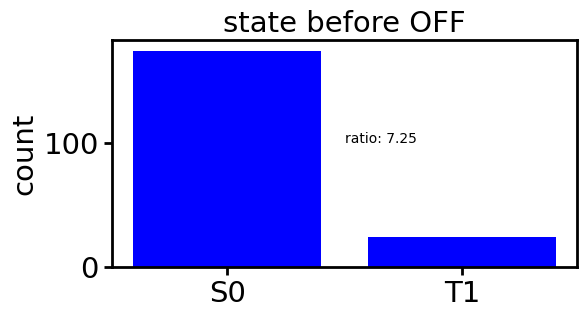

In [28]:
axes = fi.universal_figure(type_='bar', data=[['S0', 'T1'], numbers], ylabel='count', title='state before OFF', xlabel=None)
axes[0, 0].text(x=0.5, y=100, s=f'ratio: {numbers[0]/numbers[1]}')

### Concentration of reducing agent has linear effect on T1 decay rate

In [2]:
triplet_lifetimes = []
rs_concs = []
concentrations = np.arange(10, 150, 10)
for conc in concentrations:
    remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET']
    fluorophores = fl.construct_fluorophores('cy5', 3, 1)
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False, concentration=conc)
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
    transition_set.finalize()
    
    simulation = si.Simulation(transition_set)
    simulation.run(size=int(5e5), end_time=None, seed=3)
    
    analysis = st.Analysis(simulation)
    rs_conc = fo.henderson_hasselbalch_equation(ph=8, pka=9.6, concentration=conc)
    rs_concs.append(rs_conc)
    triplet_lifetime = analysis.mean_lifetimes[2]
    triplet_lifetimes.append(triplet_lifetime)

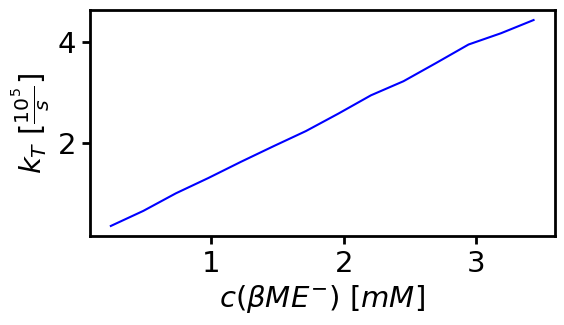

In [21]:
_ = fi.universal_figure(type_='line', data=[rs_concs, 1/np.array(triplet_lifetimes)],
                        ylabel=r'$k_T \ [\frac{10^{5}}{s}]$', tick_style_y='sci', xlabel=r'$c(\beta ME^{-}) \ [mM]$')

### Increase in irradiance leads to smaller ON times

In [29]:
on_times = []

irradiances = np.arange(0.1, 10, 0.1)
for irradiance in irradiances:
    remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET']
    fluorophores = fl.construct_fluorophores('cy5', 3, 1)
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=640, bleaching=False)
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
    transition_set.finalize()
    
    simulation = si.Simulation(transition_set)
    simulation.run(size=int(5e5), end_time=None, seed=3)
    emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1ms', emccd_gain=None, seed=4)
    blinking = bl.Blinking(emissions)
    on_times.append(blinking.on_periods.mean())

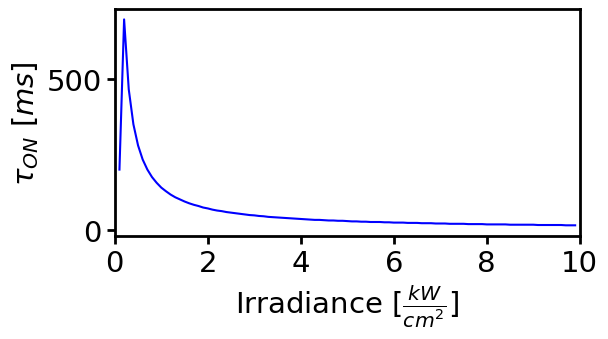

In [35]:
_ = fi.universal_figure(data=[irradiances, on_times], type_='line', xlim=[0, 10], ylabel=r'$\tau_{ON} \ [ms]$', xlabel=r'Irradiance $[\frac{kW}{cm^{2}}]$')

In [41]:
on_times = []

irradiances = np.arange(0.1, 10, 0.1)
for irradiance in irradiances:
    remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET']
    fluorophores = fl.construct_fluorophores('cy5', 3, 1)
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=640, bleaching=False)
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
    transition_set.finalize()
    
    simulation = si.Simulation(transition_set)
    simulation.run(size=int(5e5), end_time=None, seed=3)
    emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1ms', emccd_gain=None, seed=4)
    blinking = bl.Blinking(emissions)
    on_times.append(blinking.on_periods.mean())

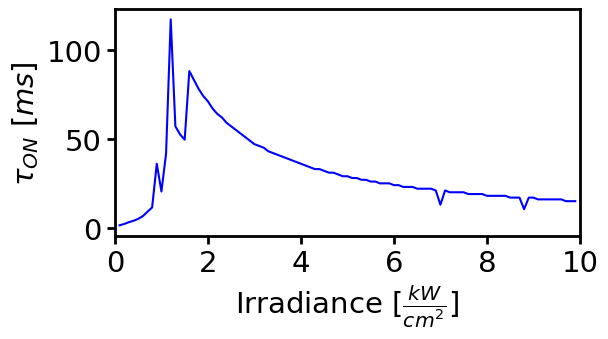

In [42]:
_ = fi.universal_figure(data=[irradiances, on_times], type_='line', xlim=[0, 10], ylabel=r'$\tau_{ON} \ [ms]$', xlabel=r'Irradiance $[\frac{kW}{cm^{2}}]$')